In [1]:
from pathlib import Path
import wfdb
import os
import numpy as np
import pandas as pd
import neurokit2 as nk

In [11]:
# npy 파일 불러오기
data = np.load('beats_signals.npy')

# 1. 데이터의 구조 확인 (개수, 길이)
print(f"데이터 모양: {data.shape}") 

# 2. 실제 데이터 일부 출력
print(data[:5]) # 앞의 5개만 확인

# 데이터의 최솟값 확인
print(f"데이터의 최솟값: {np.min(data)}")

# 만약 최솟값이 0보다 크다면 모든 값이 양수인 것입니다.

# 음수인 데이터의 개수 확인
negative_count = np.sum(data < -5)
print(f"음수 데이터 개수: {negative_count}개")

데이터 모양: (118173, 585)
[[0.215 0.215 0.215 ... 0.27  0.265 0.26 ]
 [0.215 0.215 0.21  ... 0.5   0.495 0.49 ]
 [0.245 0.24  0.24  ... 0.335 0.335 0.335]
 [0.35  0.345 0.35  ... 0.345 0.35  0.35 ]
 [0.315 0.31  0.315 ... 0.27  0.275 0.27 ]]
데이터의 최솟값: -10.053
음수 데이터 개수: 113개


최솟값이 포함된 박동 인덱스: 117431


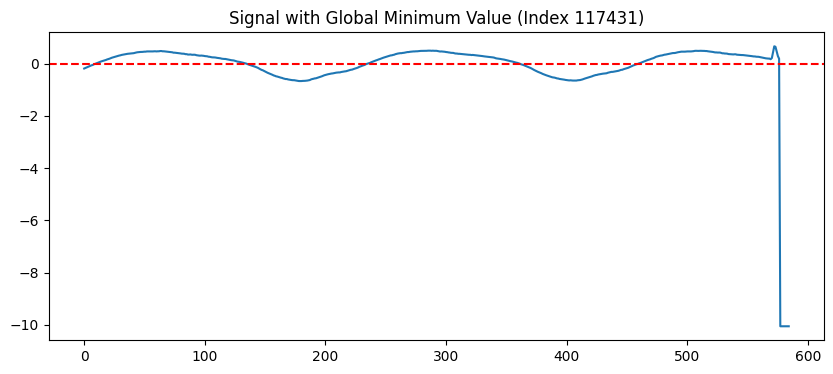

In [8]:
# 1. 음수 최솟값을 가진 박동의 인덱스 찾기
min_idx = np.argmin(np.min(data, axis=1))
print(f"최솟값이 포함된 박동 인덱스: {min_idx}")

# 2. 해당 박동 그려보기
plt.figure(figsize=(10, 4))
plt.plot(data[min_idx])
plt.title(f"Signal with Global Minimum Value (Index {min_idx})")
plt.axhline(0, color='red', linestyle='--') # 0점 기준선
plt.show()

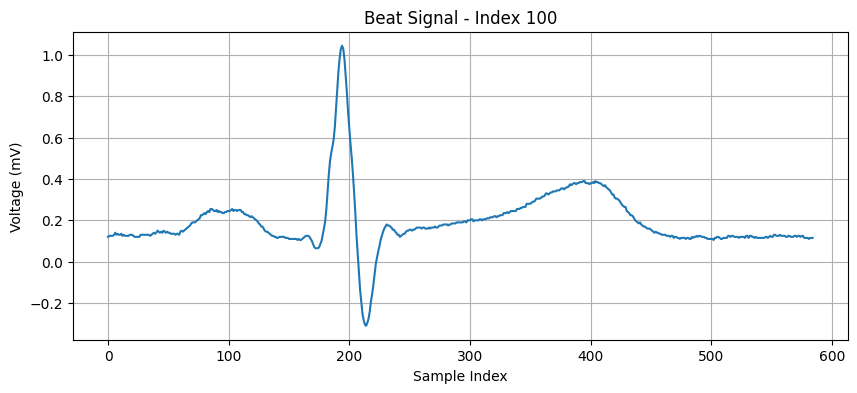

In [3]:
import matplotlib.pyplot as plt

# 11만 개 중 궁금한 인덱스 번호 (예: 100번째)
idx = 100

plt.figure(figsize=(10, 4))
plt.plot(data[idx])
plt.title(f"Beat Signal - Index {idx}")
plt.xlabel("Sample Index")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

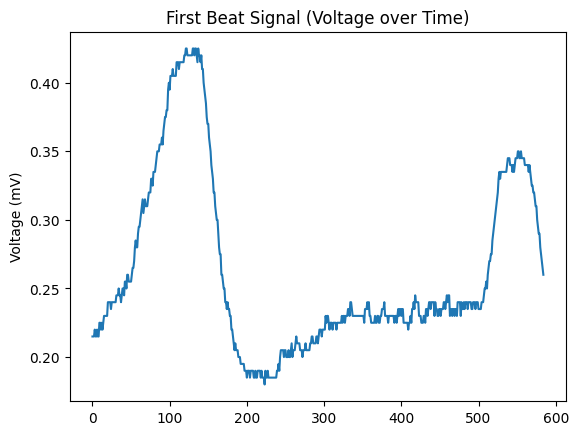

In [4]:
# 첫 번째 박동(0번 인덱스)의 585개 전압 변화를 그래프로 확인
plt.plot(data[0]) 
plt.title("First Beat Signal (Voltage over Time)")
plt.ylabel("Voltage (mV)")
plt.show()

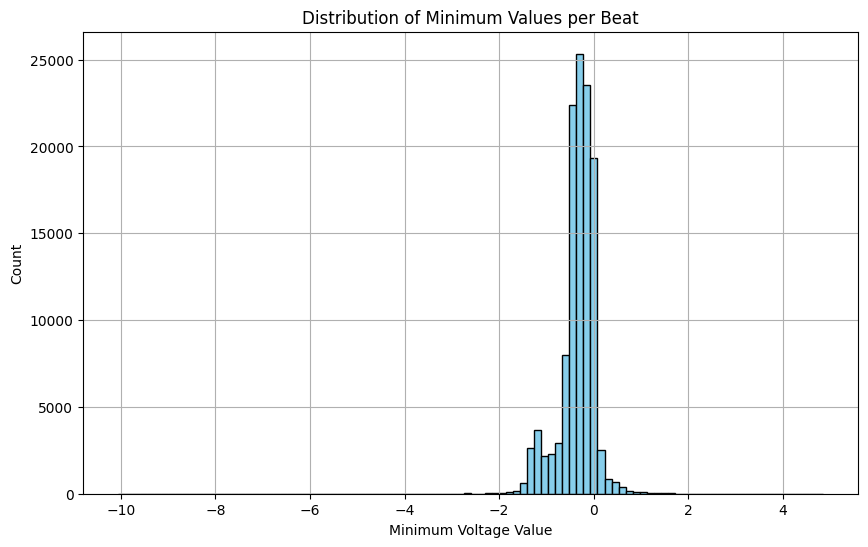

In [12]:
import matplotlib.pyplot as plt

# 모든 박동의 최솟값 리스트 추출
mins = np.min(data, axis=1)

# 최솟값들의 분포 그리기
plt.figure(figsize=(10, 6))
plt.hist(mins, bins=100, color='skyblue', edgecolor='black')
plt.title("Distribution of Minimum Values per Beat")
plt.xlabel("Minimum Voltage Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [2]:
df = pd.read_csv('beat_features_full.csv')

In [3]:
df.head()

,record_idx,fs,sig_len,hr_bpm,qrs_width_s,rr_cv,amplitude_mV
0,0,977,585,NaN,NaN,NaN,0.235
1,1,977,585,NaN,NaN,NaN,0.280
2,2,977,585,NaN,NaN,NaN,0.335
3,3,977,585,NaN,NaN,NaN,0.400
4,4,977,585,NaN,NaN,NaN,0.340


In [2]:
ROOT = Path(r"../ARRY")

# x*** 같은 레코드 파일 있는지 확인
records = sorted([p.stem for p in ROOT.glob("x*")])
print(len(records))
print(records[:10])

117
['x001', 'x001', 'x001', 'x0010', 'x0010', 'x0010', 'x0011', 'x0011', 'x0011', 'x0012']


## 모든 ECG 데이터에 있는 파일을 한 사이클 단위로 잘라서 추출

In [9]:
def extract_all_beats(data_path, before_sec=0.2, after_sec=0.4):
    all_beats = []
    all_metadata = []

    # 1. 폴더 내 모든 파일 리스트 확인 (확장자 제외한 파일명만 추출)
    file_list = sorted(list(set([f.split('.')[0] for f in os.listdir(data_path) if f.endswith('.dat')])))

    print(f"총 {len(file_list)}개의 레코드를 발견했습니다.")

    for file_name in file_list:
        try:
            file_path = os.path.join(data_path, file_name)
            
            # 2. 신호 데이터(.dat)와 주석(.atr) 읽기
            record = wfdb.rdrecord(file_path)
            annotation = wfdb.rdann(file_path, 'atr')
            
            fs = record.fs
            signal = record.p_signal[:, 1] # 보통 Lead II 신호 선택 (데이터에 따라 인덱스 조절)
            
            # 3. 자를 범위 설정 (샘플 개수 단위로 변환)
            before_samples = int(before_sec * fs)
            after_samples = int(after_sec * fs)
            
            # 4. 각 R-peak 지점을 순회하며 자르기
            for i, r_peak in enumerate(annotation.sample):
                # 신호의 범위를 벗어나지 않는지 확인
                if r_peak - before_samples > 0 and r_peak + after_samples < len(signal):
                    beat = signal[r_peak - before_samples : r_peak + after_samples]
                    
                    # 데이터와 함께 메타데이터(어떤 환자, 어떤 라벨인지) 저장
                    all_beats.append(beat)
                    all_metadata.append({
                        'patient_id': file_name,
                        'label': annotation.symbol[i], # 'N', 'V', 'A' 등의 주석 기호
                        'peak_index': r_peak
                    })
                    
        except Exception as e:
            print(f"파일 {file_name} 처리 중 오류 발생: {e}")

    return np.array(all_beats), pd.DataFrame(all_metadata)

# 실행 예시
data_folder = '../ARRY' # 데이터가 저장된 폴더 경로로 수정하세요
beats_data, metadata_df = extract_all_beats(data_folder)

print(f"추출 완료! 총 박동 수: {len(beats_data)}")
print(metadata_df.head())

총 39개의 레코드를 발견했습니다.
추출 완료! 총 박동 수: 118173
  patient_id label  peak_index
0       x001     ~       93691
1       x001     +       93981
2       x001     N       94109
3       x001     N       94851
4       x001     N       95579


In [ ]:
# numpy 배열로 저장 (신호 데이터)
np.save('beats_signals.npy', beats_data)

# csv로 저장 (환자 정보 및 라벨)
metadata_df.to_csv('beats_metadata.csv', index=False) #잘린 배열이 어떻게 저장되는지

In [ ]:
import wfdb
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path(r"../ARRY")

records = sorted(set([p.stem for p in ROOT.glob("x*")]))  # 중복 제거
print(len(records), records[:10])

def extract_features_from_record(rec_name: str) -> pd.DataFrame:
    """
    일단 구조 테스트용: record 단위 한 줄만 만드는 버전.
    나중에 여기에 RR, HR, QRS 폭, P-wave feature를 추가 가능
    """
    path = ROOT / rec_name
    header = wfdb.rdheader(str(path))

    fs = header.fs
    sig_len = header.sig_len

    # TODO: 여기 HR, RR, QRS width 추출 코드 추가 예정
    hr_bpm = np.nan
    qrs_width_s = np.nan
    rr_cv = np.nan
    p_wave_present = np.nan
    amplitude_mV = np.nan

    row = {
        "record": rec_name,
        "fs": fs, #초당 주파수(헤르츠) - 1초당 얼마나 많은 주파수가 나오는지
        "sig_len": sig_len,
        "hr_bpm": hr_bpm,
        "qrs_width_s": qrs_width_s,
        "rr_cv": rr_cv,
        "p_wave_present": p_wave_present,
        "amplitude_mV": amplitude_mV,
        "artifact": False,
        "pad_contact_ok": True,
    }
    return pd.DataFrame([row])

dfs = [extract_features_from_record(r) for r in records]
print(len(dfs), type(dfs[0]))

all_features = pd.concat(dfs, ignore_index=True)
all_features.head()

39 ['x001', 'x0010', 'x0011', 'x0012', 'x0013', 'x0014', 'x0015', 'x0016', 'x0017', 'x0018']
39 <class 'pandas.core.frame.DataFrame'>


,record,fs,sig_len,hr_bpm,qrs_width_s,rr_cv,p_wave_present,amplitude_mV,artifact,pad_contact_ok
0,x001,977,8528429,NaN,NaN,NaN,NaN,NaN,False,True
1,x0010,977,310260,NaN,NaN,NaN,NaN,NaN,False,True
2,x0011,977,700543,NaN,NaN,NaN,NaN,NaN,False,True
3,x0012,977,683203,NaN,NaN,NaN,NaN,NaN,False,True
4,x0013,977,228716,NaN,NaN,NaN,NaN,NaN,False,True


### 1. 레코드 목록 + neurokit2 기반 feature 추출

In [9]:
# npy 파일 로드
records_data = np.load('beats_signals.npy')

# 데이터 구조 확인 (개수, 신호 길이)
print(f"데이터 개수: {len(records_data)}")
print(f"첫 번째 신호의 샘플 개수: {len(records_data[0])}")

데이터 개수: 118173
첫 번째 신호의 샘플 개수: 585


#### sampling rate 읽는 법

In [17]:
# 레코드 읽기
record = wfdb.rdrecord('../ARRY/x001')

# 샘플링 레이트 출력
print(f"이 데이터의 샘플링 레이트는 {record.fs}Hz 입니다.")

이 데이터의 샘플링 레이트는 977Hz 입니다.


In [ ]:
# 희진쌤 코드를 npy 데이터용으로 수정한 버전
def extract_features_from_array(sig_array, fs, idx):
    """
    신호 배열(sig_array)을 직접 입력받음
    """
    # 1) ECG clean
    cleaned = records_data

    # 2) R-peak 검출
    try:
        # 전처리를 생략했으므로 고전적인 방법으로 피크 탐지
        _, info = nk.ecg_peaks(cleaned, sampling_rate=fs, method="neurokit")
        rpeaks = info["ECG_R_Peaks"]
    except:
        # 피크를 못 찾으면 강제로 중간 지점을 지정 (우리가 그렇게 잘랐으니까요!)
        rpeaks = [len(cleaned) // 2]

    # 기본값 설정 및 특징 추출 로직
    hr_bpm = np.nan
    rr_cv = np.nan
    qrs_width_s = np.nan


    if len(rpeaks) >= 3:
        rr = np.diff(rpeaks) / fs
        # 데이터가 비어있지 않은지 확인
        if len(rr) > 0:
            hr_inst = 60.0 / rr
            hr_bpm = float(np.nanmedian(hr_inst))
            rr_cv = float(np.nanstd(rr) / np.nanmean(rr))

        try:
            _, waves_peak = nk.ecg_delineate(cleaned, rpeaks, sampling_rate=fs, method="dwt")
            q_peaks = np.array(waves_peak.get("ECG_Q_Peaks", []))
            s_peaks = np.array(waves_peak.get("ECG_S_Peaks", []))

        # ★ 수정 포인트: 데이터가 유효한지(NaN이 아니고 개수가 있는지) 체크
            mask = ~np.isnan(q_peaks) & ~np.isnan(s_peaks)
            valid_q = q_peaks[mask]
            valid_s = s_peaks[mask]

            if len(valid_q) > 0 and len(valid_s) > 0:
                n = min(len(valid_q), len(valid_s))
                diffs = (valid_s[:n] - valid_q[:n]) / fs
                if len(diffs) > 0: # 여기서 한 번 더 체크!
                    q_width = np.nanmedian(diffs)
                    qrs_width_s = float(q_width) if not np.isnan(q_width) else np.nan
        except Exception:
            qrs_width_s = np.nan

    amplitude_mV = float(np.nanmedian(np.abs(cleaned)))

    # 결과물 구성
    row = {
        "record_idx": idx, # 파일명 대신 인덱스 번호 사용
        "fs": fs,
        "sig_len": len(sig_array),
        "hr_bpm": hr_bpm,
        "qrs_width_s": qrs_width_s,
        "rr_cv": rr_cv,
        "amplitude_mV": amplitude_mV,
    }
    return pd.DataFrame([row])

# 3. 모든 npy 데이터에 대해 실행
# 샘플링 레이트(fs)는 원본 데이터에 맞춰 설정하세요 (예: 500)
sampling_rate = 977

dfs = []
for i in range(len(records_data)): #전체
#일부만
#for i in range(100): 
    df = extract_features_from_array(records_data[i], sampling_rate, i)
    dfs.append(df)

# 하나로 합치기
all_features = pd.concat(dfs, ignore_index=True)
print(all_features.head())